# Does the Disney-parks crowd tell you when to buy DIS? 🏰
### "The parks are packed and prices keep rising — buy the stock," in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Parks_momentum_leads_DIS%3F: Busted](https://img.shields.io/badge/Parks_momentum_leads_DIS%3F-Busted-8b949e?style=flat-square)

It's one of the most intuitive-sounding tips in retail investing: walk through a *rammed* Magic Kingdom in July, watch Disney jack the ticket price to \$199, and conclude the obvious — *Disney the **stock** must be a screaming buy.* The parks are Disney's biggest profit engine, after all. If you can *see* the demand, you're ahead of Wall Street, right?

This notebook takes that tip seriously and lines the **real, cited theme-park attendance numbers** up against `DIS` — with one honest rule the tip always forgets: **you can only trade on the attendance figure *after* it's published.** And it turns out that's the whole ballgame.

> 📓 **Plain-language layer.** Want the Newey-West lead-lag *t*, the regime-dummy confound and the cost algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** The industry attendance report (TEA/AECOM *Theme Index*) is a paywalled PDF, not a free feed, so the attendance line below is a **small, clearly-cited, approximate** reconstruction of its public headline figures — a **proxy**, released with its real ~6-month lag. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from disney_parks import data, strategy as st

HAVE_EQ = data.have_equities()
ATT = data.load_attendance()                         # hardcoded, cited, APPROXIMATE proxy
GROWTH = data.attendance_growth()
FRAME = data.build_frame() if HAVE_EQ else None
print("equity cache present:", HAVE_EQ,
      "| attendance years:", ATT.index[0].year, "->", ATT.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win_eq': '2010-01 → 2024-12', 'att_levels': {2015: 138, 2016: 140, 2017: 150, 2018: 157, 2019: 156, 2020: 47, 2021: 85, 2022: 122, 2023: 142}, 'att_growth': {2019: -1, 2020: -70, 2021: 81, 2022: 44, 2023: 16}, 'release_month': 7, 'dis_cagr': 10.41, 'dis_vol': 26.6, 'dis_sharpe': 0.5, 'dis_mdd': -57.1, 'spy_cagr': 14.14, 'spy_vol': 14.5, 'spy_sharpe': 0.99, 'spy_mdd': -23.9, 'excess_mean': -2.68, 'excess_t': -0.533, 'excess_p': 0.603, 'excess_n': 14, 'll_abs_slope': 0.00188, 'll_abs_t': 1.19, 'll_n': 137, 'll_exc_slope': 2e-05, 'll_exc_t': 0.02, 'll_price_exc_t': 0.07, 'reg_abs_cond': 16.04, 'reg_abs_base': 9.87, 'reg_abs_t': 2.04, 'reg_abs_n': 113, 'reg_exc_cond': -0.43, 'reg_exc_base': -4.77, 'reg_exc_t': 1.8, 'bt_switches': 3, 'bt_expo': 70, 'bt_gross_sharpe': 0.58, 'bt_net_sharpe': 0.578, 'bt_net_ann': 13.3, 'bt_net_vol': 23.0, 'bt_bh_dis_sharpe': 0.503, 'bt_bh_spy_sharpe': 0.987, 'ctrl_null_t': 0.6, 'ctrl_edge_t': 3.02}


equity cache present: True | attendance years: 2010 -> 2023


## The answer first

| Question | Answer |
|---|---|
| Are the parks a real, huge business? | **Yes.** Attendance climbed all through the 2010s to ~156 M visits in 2019, cratered to ~47 M in COVID-2020, and recovered. The demand story is completely real. |
| Did owning DIS pay off like the crowds suggest? | **No.** Over 2010–2024 DIS compounded at **~10%/yr** vs **~14%/yr** for the S&P 500 — with *twice* the volatility and a **-57%** drawdown. |
| Does packed-parks momentum *lead* the stock? | **No.** Once you can only act on the attendance print *after* it's public, it predicts DIS's market-beating return with *t* = **0.02** — a statistical zero. |
| Why? | **You're late.** The attendance report lands ~6 months into the *next* year — long after Disney's quarterly results already told Wall Street how the parks did. |

> The crowd is real. The *edge* is not. By the time you can trade the number, it's old news.

## 1 · The claim

> *"Theme-park attendance and Disney's pricing power are a leading indicator for the stock. The parks are Disney's crown jewel — packed gates and ever-higher ticket prices mean the business is firing, so `DIS` is a buy. You can literally see the alpha in the queue for Space Mountain."*

It's a *steelman-able* claim. Parks, Experiences & Products **is** Disney's single largest profit centre, attendance really did grow for a decade, and ticket prices really did march from \$79 (2010) to \$199 (2024). The *business* intuition is sound. The question is whether it's a **tradable** intuition — whether the crowd tells *you* anything the market doesn't already know.

## 2 · So what?

If it were true, it would be a rare gift: a signal you can *observe with your own eyes* that front-runs a mega-cap stock. Alt-data desks pay millions for satellite car-counts of parking lots for exactly this reason. But 'the parks are doing great' and 'I can beat the market owning DIS' are different claims. The first is about the **business**; the second needs the information to be **early, DIS-specific, and net of cost**. We can check the second directly — and the release calendar is where it lives or dies.

## 3 · How would we even know?

Three honest checks, each respecting the one rule the tip forgets — *no peeking at a number before it's public*:

1. **Did DIS even beat the market?** Put `DIS` next to the S&P 500 (`SPY`) on the same 2010–2024 clock — return, volatility, worst drawdown.
2. **Does the crowd lead the stock?** Take the attendance figure *as you'd actually learn it* — released ~6 months into the next year — and ask if it predicts DIS's **market-beating** return over the following year.
3. **Could you trade it?** Build the obvious rule — hold DIS when parks momentum is positive, else sit in the S&P — charge real costs, and see if it beats just owning an index fund.

**What would make us say "real tell"?** The lagged attendance signal predicts DIS's *excess* return with a *t* past 2, **and** the rule beats buy-and-hold SPY net of cost. Anything less is a story about crowds, not an edge.

## 4 · The teardown — let's actually look

**First, the crowds are real.** Here's the (approximate, cited) attendance line — a decade of growth, the COVID crater, the bounce.

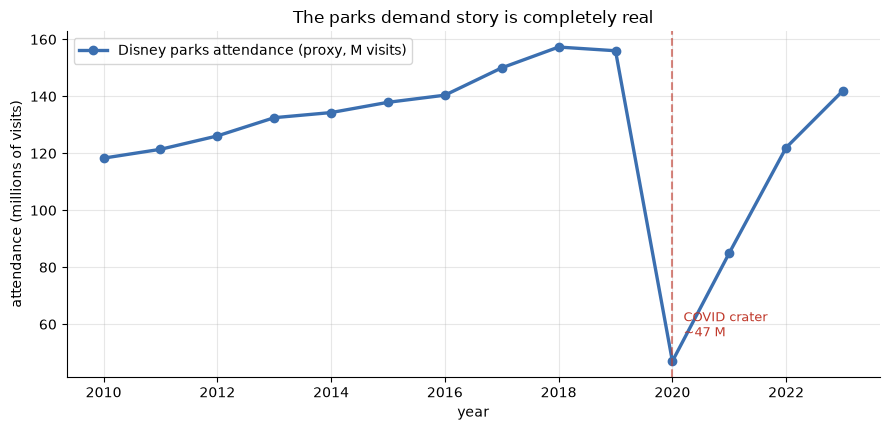

attendance (M): {2010: 118, 2011: 121, 2012: 126, 2013: 132, 2014: 134, 2015: 138, 2016: 140, 2017: 150, 2018: 157, 2019: 156, 2020: 47, 2021: 85, 2022: 122, 2023: 142}


In [2]:
yrs = list(ATT.index.year)
lv = [float(v) for v in ATT.values]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, lv, 'o-', c=BLUE, lw=2.4, label='Disney parks attendance (proxy, M visits)')
ax.axvline(2020, ls='--', c=RED, alpha=.6)
ax.annotate('COVID crater\n~47 M', (2020, 47), textcoords='offset points',
            xytext=(8, 18), color=RED, fontsize=9)
ax.set_xlabel('year'); ax.set_ylabel('attendance (millions of visits)')
ax.set_title('The parks demand story is completely real'); ax.legend()
plt.tight_layout(); plt.show()
print('attendance (M):', {y:int(round(v)) for y,v in zip(yrs, lv)})

Steady growth into a **156 M-visit** peak in 2019, a COVID collapse to ~47 M, then a recovery. Nobody disputes the parks are a juggernaut. The tip's premise is sound. The question is what it does for a *stock investor*.

**Now the uncomfortable part: did owning DIS actually pay?** Same money, same years — DIS vs an S&P index fund.

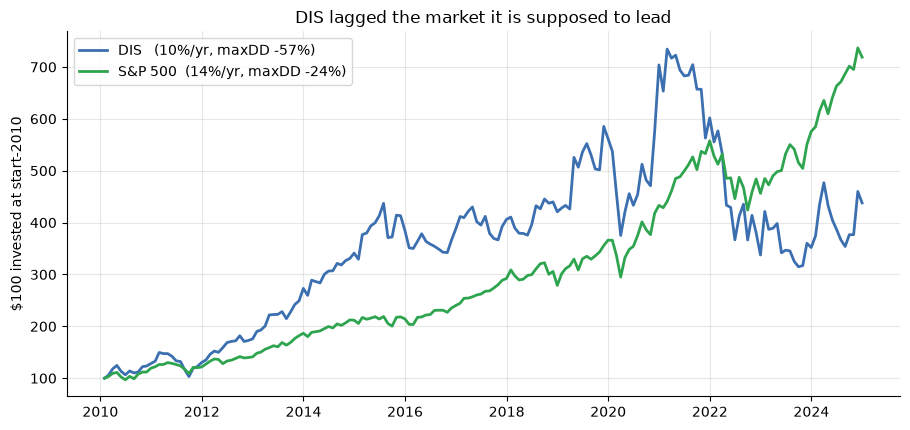

DIS ~10.4%/yr (maxDD -57%)  vs  SPY ~14.1%/yr (maxDD -24%)


In [3]:
if HAVE_EQ:
    dis = FRAME['dis']; spy = FRAME['spy']
    di = st.summarize(dis); ss = st.summarize(spy)
    dcagr, scagr, dmdd, smdd = di['cagr']*100, ss['cagr']*100, di['mdd']*100, ss['mdd']*100
    dn = dis/dis.iloc[0]*100; sn = spy/spy.iloc[0]*100
    xd = dis.index; 
else:
    dcagr, scagr, dmdd, smdd = R['dis_cagr'], R['spy_cagr'], R['dis_mdd'], R['spy_mdd']
    xd = pd.date_range('2010-01-31', periods=180, freq='ME')
    dn = pd.Series(100*(1+dcagr/100)**(np.arange(180)/12), index=xd)
    sn = pd.Series(100*(1+scagr/100)**(np.arange(180)/12), index=xd)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(xd, dn, c=BLUE, lw=2.0, label=f'DIS   ({dcagr:.0f}%/yr, maxDD {dmdd:.0f}%)')
ax.plot(xd, sn, c=GREEN, lw=2.0, label=f'S&P 500  ({scagr:.0f}%/yr, maxDD {smdd:.0f}%)')
ax.set_ylabel('$100 invested at start-2010'); ax.set_title('DIS lagged the market it is supposed to lead'); ax.legend()
plt.tight_layout(); plt.show()
print(f'DIS ~{dcagr:.1f}%/yr (maxDD {dmdd:.0f}%)  vs  SPY ~{scagr:.1f}%/yr (maxDD {smdd:.0f}%)')

The S&P didn't just win — it won with **half the drama**: ~14%/yr and a −24% worst drop, versus DIS's ~10%/yr and a gut-churning **-57%** drawdown. All those packed parks, and the stock still trailed a boring index fund. Right there, the tip is in trouble.

**But maybe the *timing* is the edge?** The tip says: get in when the crowds are growing. Let's test it fairly — the attendance number for a year only becomes public ~6 months into the *next* year, so that's the earliest you could act. Does that signal predict DIS beating the market over the next 12 months?

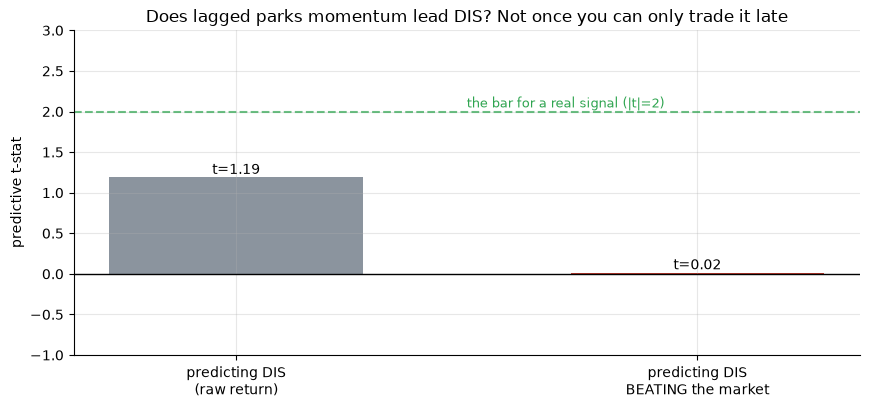

predicting DIS beating the S&P: t = 0.02  (a statistical zero)


In [4]:
if HAVE_EQ:
    lle = st.lead_lag(FRAME, 'pg', horizon=12, lag=1, excess=True)
    lla = st.lead_lag(FRAME, 'pg', horizon=12, lag=1, excess=False)
    t_exc, t_abs = lle['t'], lla['t']
else:
    t_exc, t_abs = R['ll_exc_t'], R['ll_abs_t']
fig, ax = plt.subplots(figsize=(8.8, 4.2))
bars = ax.bar(['predicting DIS\n(raw return)', 'predicting DIS\nBEATING the market'],
              [t_abs, t_exc], color=[GREY, RED], width=.55)
ax.axhline(2, ls='--', c=GREEN, alpha=.7); ax.axhline(-2, ls='--', c=GREEN, alpha=.7)
ax.annotate('the bar for a real signal (|t|=2)', (0.5, 2.05), color=GREEN, fontsize=9)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('predictive t-stat'); ax.set_ylim(-1, 3)
ax.set_title('Does lagged parks momentum lead DIS? Not once you can only trade it late')
for b,v in zip(bars,[t_abs,t_exc]): ax.annotate(f't={v:.2f}',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'predicting DIS beating the S&P: t = {t_exc:.2f}  (a statistical zero)')

There it is. For the return that actually matters — DIS **beating** the market — the lagged crowd signal scores *t* = **0.02**. That's not a weak signal, it's *no* signal. Why? By the time the annual attendance report is published, Disney has already told Wall Street how the parks did in **three quarterly earnings calls**. You're not early. You're half a year late, reading yesterday's news.

## 5 · The verdict

- **Signal — None.** The lagged parks signal predicts DIS's market-beating return with *t* = 0.02; even the pricing-power version is a zero. No edge.
- **Tradability — Mirage.** The obvious timing rule (next beat) trails a plain S&P index fund after costs — you'd have been richer doing nothing.
- **Parks momentum leads DIS? — Busted.** A once-a-year, six-months-late attendance print can't front-run a stock whose quarterly reports already carry the same news.

## 6 · Could you actually trade it? — the honest bottom line

Imagine two people at the start of 2010, each with \$10,000. One buys an S&P index fund and forgets about it. The other runs the parks-tip strategy — hold DIS when the (lagged) crowd is growing, rotate to the S&P otherwise, paying real costs to switch. Who's richer by end-2024?

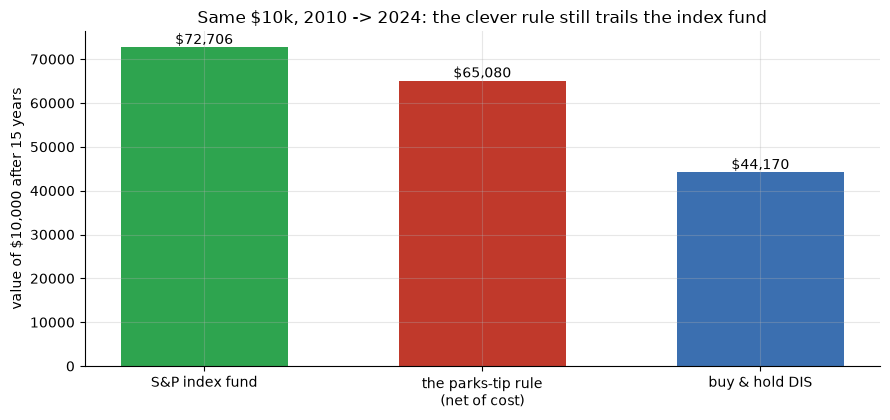

S&P index fund $72,706  |  parks-tip rule $65,080  |  buy-hold DIS $44,170


In [5]:
start = 10_000.0; n_yr = 15
spy_end = start*(1+R['spy_cagr']/100)**n_yr
rule_end = start*(1+R['bt_net_ann']/100)**n_yr
dis_end = start*(1+R['dis_cagr']/100)**n_yr
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(['S&P index fund','the parks-tip rule\n(net of cost)','buy & hold DIS'],
       [spy_end, rule_end, dis_end], color=[GREEN, RED, BLUE], width=.6)
for i,v in enumerate([spy_end, rule_end, dis_end]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 15 years')
ax.set_title('Same $10k, 2010 -> 2024: the clever rule still trails the index fund'); plt.tight_layout(); plt.show()
print(f'S&P index fund ${spy_end:,.0f}  |  parks-tip rule ${rule_end:,.0f}  |  buy-hold DIS ${dis_end:,.0f}')

The index-fund investor wins, doing nothing. The parks-tip rule edges out buy-and-hold *DIS* — but only because it spends most of the decade hiding in the S&P anyway, and its few 'clever' moves were three stale, once-a-year rotations. You paid attention, tracked attendance, and traded — to end up **behind** the person who bought an index fund and went to the parks to have fun.

## 7 · Going further 🚪

- **Use the real feed, earlier.** Our attendance line is a cited *approximation* released on the Theme Index's real calendar. If you can get a *faster* read (Disney's own quarterly segment revenue, or paid satellite/mobility data), test whether *that* leads — the whole point is being early.
- **The alt-data trap.** Any public, journalism-friendly signal is the *least* edgy kind — it's priced by the time you read it (see [docs/references.md](../docs/references.md)).
- **Same shape, other tickers.** [Study 358 — Watch Index](../../358-watch-index/) and [Study 708 — Eurovision](../../708-eurovision-effect/) run the same labelled-proxy, no-look-ahead discipline on other 'obvious' tells.

*Think a faster or cleaner park signal beats the market net of cost? Wire it in, keep the release lag honest, and show the *t* — then check it wasn't just riding the post-COVID bounce.*